# Capstone Project: Short-Term Reversal Following High-Volume Price Declines in Indian Equities

## Research Question

Do extreme negative daily returns accompanied by unusually high trading volume exhibit short-term price reversal among large-cap Indian equities?

## Hypothesis

Large negative daily returns accompanied by abnormally high trading volume may be followed by positive short-horizon returns. One possible mechanism is that unusually intense trading during sharp price declines reflects temporary selling pressure or investor overreaction. Subsequent buying may then produce partial short-term price reversal.

This hypothesis will be tested empirically and may be rejected if the proposed effect is not supported by the data, particularly out-of-sample.

## 1. Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

### 1.1 Research Universe

The study focuses on a fixed universe of large-cap Indian equities. A fixed universe is used to provide a transparent and reproducible sample for testing the relationship between extreme negative returns, unusually high trading volume, and subsequent short-term returns.

The universe is defined explicitly rather than assuming that current constituents represent historical NIFTY 50 membership throughout the sample period. The implications of this choice, including potential survivorship and selection bias, are discussed later in the methodology and pitfall analysis.

In [2]:
universe = pd.read_csv("data/ind_nifty50list.csv")

universe.head()

,Company Name,Industry,Symbol,Series,ISIN Code
0,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024
1,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042
2,Apollo Hospitals Enterprise Ltd.,Healthcare,APOLLOHOSP,EQ,INE437A01024
3,Asian Paints Ltd.,Consumer Durables,ASIANPAINT,EQ,INE021A01026
4,Axis Bank Ltd.,Financial Services,AXISBANK,EQ,INE238A01034


In [3]:
print("Number of companies:", len(universe))
print("Number of unique symbols:", universe["Symbol"].nunique())

Number of companies: 50
Number of unique symbols: 50


In [4]:
tickers = universe["Symbol"].astype(str) + ".NS"

tickers.head()

0      ADANIENT.NS
1    ADANIPORTS.NS
2    APOLLOHOSP.NS
3    ASIANPAINT.NS
4      AXISBANK.NS
Name: Symbol, dtype: str

In [5]:
raw_data = yf.download(
    tickers.tolist(),
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    group_by="ticker",
    progress=True
)

[*********************100%***********************]  50 of 50 completed


In [6]:
print("Dataset shape:", raw_data.shape)
print("First date:", raw_data.index.min())
print("Last date:", raw_data.index.max())

Dataset shape: (2716, 300)
First date: 2015-01-01 00:00:00
Last date: 2025-12-31 00:00:00


In [7]:
data_counts = {}

for ticker in tickers:
    data_counts[ticker] = raw_data[ticker]["Close"].notna().sum()

data_counts = pd.Series(data_counts).sort_values()

data_counts

JIOFIN.NS         584
ETERNAL.NS       1099
MAXHEALTH.NS     1328
HDFCLIFE.NS      2006
SBILIFE.NS       2038
BSE.NS           2201
INDIGO.NS        2504
ASIANPAINT.NS    2716
BAJFINANCE.NS    2716
BAJAJFINSV.NS    2716
BHARTIARTL.NS    2716
BEL.NS           2716
CIPLA.NS         2716
AXISBANK.NS      2716
APOLLOHOSP.NS    2716
ADANIENT.NS      2716
EICHERMOT.NS     2716
DRREDDY.NS       2716
COALINDIA.NS     2716
GRASIM.NS        2716
HINDALCO.NS      2716
HINDUNILVR.NS    2716
HCLTECH.NS       2716
HDFCBANK.NS      2716
ITC.NS           2716
ICICIBANK.NS     2716
INFY.NS          2716
JSWSTEEL.NS      2716
KOTAKBANK.NS     2716
LT.NS            2716
BAJAJ-AUTO.NS    2716
ADANIPORTS.NS    2716
MARUTI.NS        2716
M&M.NS           2716
NESTLEIND.NS     2716
NTPC.NS          2716
ONGC.NS          2716
POWERGRID.NS     2716
RELIANCE.NS      2716
SHRIRAMFIN.NS    2716
SBIN.NS          2716
SUNPHARMA.NS     2716
TCS.NS           2716
TATACONSUM.NS    2716
TMPV.NS          2716
TATASTEEL.

In [8]:
first_valid_dates = {}

for ticker in tickers:
    first_valid_dates[ticker] = raw_data[ticker]["Close"].first_valid_index()

first_valid_dates = pd.Series(first_valid_dates).sort_values()

first_valid_dates

ADANIENT.NS     2015-01-01
JSWSTEEL.NS     2015-01-01
KOTAKBANK.NS    2015-01-01
LT.NS           2015-01-01
M&M.NS          2015-01-01
MARUTI.NS       2015-01-01
NTPC.NS         2015-01-01
NESTLEIND.NS    2015-01-01
ONGC.NS         2015-01-01
POWERGRID.NS    2015-01-01
RELIANCE.NS     2015-01-01
SHRIRAMFIN.NS   2015-01-01
SBIN.NS         2015-01-01
SUNPHARMA.NS    2015-01-01
TCS.NS          2015-01-01
TATACONSUM.NS   2015-01-01
TMPV.NS         2015-01-01
TATASTEEL.NS    2015-01-01
TECHM.NS        2015-01-01
TITAN.NS        2015-01-01
TRENT.NS        2015-01-01
ITC.NS          2015-01-01
INFY.NS         2015-01-01
HINDUNILVR.NS   2015-01-01
ADANIPORTS.NS   2015-01-01
APOLLOHOSP.NS   2015-01-01
ASIANPAINT.NS   2015-01-01
AXISBANK.NS     2015-01-01
BAJAJ-AUTO.NS   2015-01-01
BAJFINANCE.NS   2015-01-01
BAJAJFINSV.NS   2015-01-01
BEL.NS          2015-01-01
BHARTIARTL.NS   2015-01-01
ICICIBANK.NS    2015-01-01
COALINDIA.NS    2015-01-01
CIPLA.NS        2015-01-01
EICHERMOT.NS    2015-01-01
G

### 1.2 Market Data

Daily OHLCV data were downloaded for the research universe using Yahoo Finance via the `yfinance` Python package. The sample covers 1 January 2015 to 31 December 2025. Prices were downloaded without automatic adjustment so that raw and adjusted price information could be inspected explicitly.

Stocks without observations for the full sample period are retained and become eligible for analysis only when valid market data are available. Missing pre-listing observations are not imputed.

A snapshot of the downloaded market data is saved in the project `data` directory to support reproducibility.

In [9]:
raw_data.to_csv("data/raw_market_data.csv")

## 2. Data Cleaning

The downloaded market data are validated and transformed before constructing the research variables. The cleaning process checks missing observations, the structure of the price data, and the treatment of corporate actions.

Stocks with shorter trading histories are retained. Observations before valid market data become available remain missing rather than being artificially imputed.

In [10]:
raw_data["RELIANCE.NS"].head()

Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-01,202.593277,203.896194,201.987518,202.959000,189.125366,2963643
2015-01-02,203.004715,204.821960,202.136108,202.421829,188.624817,7331366
2015-01-05,202.296112,203.644760,199.804550,200.204575,186.558701,10103941
2015-01-06,198.867371,199.553116,190.181198,191.118393,178.091812,18627980
2015-01-07,191.346985,196.307236,191.324127,195.278610,181.968491,20720312


### 2.1 Missing Data Validation

Missing observations are examined before constructing returns and trading signals. Missing pre-listing observations are retained as missing values rather than filled, because no genuine market observation exists for those dates.

In [11]:
missing_close = {}

for ticker in tickers:
    close = raw_data[ticker]["Close"]
    first_valid = close.first_valid_index()
    last_valid = close.last_valid_index()

    active_period = close.loc[first_valid:last_valid]
    missing_close[ticker] = active_period.isna().sum()

missing_close = pd.Series(missing_close).sort_values(ascending=False)

missing_close.head(10)

ADANIENT.NS      0
ADANIPORTS.NS    0
APOLLOHOSP.NS    0
ASIANPAINT.NS    0
AXISBANK.NS      0
BSE.NS           0
BAJAJ-AUTO.NS    0
BAJFINANCE.NS    0
BAJAJFINSV.NS    0
BEL.NS           0
dtype: int64

### 2.2 Corporate Actions and Return Prices

Adjusted closing prices are used to calculate historical daily returns. This reduces distortions arising from corporate actions such as stock splits and dividends that could otherwise appear as artificial price movements.

Raw OHLC prices are retained in the downloaded snapshot, while adjusted close prices are used for return construction. Trading volume is retained separately for the abnormal-volume component of the research signal.

In [12]:
adj_close = pd.DataFrame({
    ticker: raw_data[ticker]["Adj Close"]
    for ticker in tickers
})

volume = pd.DataFrame({
    ticker: raw_data[ticker]["Volume"]
    for ticker in tickers
})

print("Adjusted close shape:", adj_close.shape)
print("Volume shape:", volume.shape)

Adjusted close shape: (2716, 50)
Volume shape: (2716, 50)


### 2.3 Daily Returns

Daily stock returns are calculated from adjusted closing prices. Adjusted prices are used so that corporate actions do not create artificial return observations.

For stock $i$ on day $t$, the simple daily return is:

$$
R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1
$$

where $P_{i,t}$ is the adjusted closing price of stock $i$ on day $t$.

In [13]:
daily_returns = adj_close.pct_change(fill_method=None)

daily_returns.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,0.004898,-0.000626,0.001732,0.034573,0.022364,NaN,-0.000163,-0.015987,-0.008511,-0.005001,...,0.003981,0.004926,0.013318,0.011945,0.026783,0.015577,0.004895,0.007899,-0.008800,0.029897
2015-01-05,0.016552,0.013934,0.003325,-0.000065,0.006319,NaN,0.003651,-0.002613,-0.013287,-0.018891,...,-0.007930,0.000605,-0.015197,0.002951,0.023447,0.014486,-0.016684,0.008098,0.001157,0.002042
2015-01-06,-0.007592,-0.006022,-0.029780,-0.023871,-0.035745,NaN,-0.007803,-0.002591,-0.023119,-0.013226,...,-0.041087,-0.022014,-0.036867,-0.031383,-0.042764,-0.048476,-0.010726,-0.034205,-0.014033,-0.028060
2015-01-07,-0.008857,-0.002330,0.007833,0.020092,-0.000802,NaN,0.002335,0.020360,-0.000854,0.134754,...,0.000834,0.001546,-0.011812,0.002025,-0.015058,-0.019168,-0.004673,0.005098,0.025949,-0.003951


In [14]:
reliance_check = pd.DataFrame({
    "Adjusted Close": adj_close["RELIANCE.NS"],
    "Daily Return": daily_returns["RELIANCE.NS"]
})

reliance_check.head()

,Adjusted Close,Daily Return
Date,,
2015-01-01,189.125366,NaN
2015-01-02,188.624817,-0.002647
2015-01-05,186.558701,-0.010954
2015-01-06,178.091812,-0.045385
2015-01-07,181.968491,0.021768


### 2.4 Relative Trading Volume

Trading volume is normalised relative to each stock's own recent trading activity. For stock $i$ on day $t$, the 20-day historical average volume is calculated using only the previous 20 trading observations:

$$
\overline{V}_{i,t}^{(20)}
=
\frac{1}{20}
\sum_{k=1}^{20} V_{i,t-k}
$$

Relative volume (RVOL) is then defined as:

$$
RVOL_{i,t}
=
\frac{V_{i,t}}
{\overline{V}_{i,t}^{(20)}}
$$

An RVOL above 1 indicates trading volume above the stock's recent average. The current day's volume is excluded from the historical benchmark to prevent information from the event day itself from influencing the definition of normal volume.

In [15]:
average_volume_20 = volume.shift(1).rolling(window=20).mean()

relative_volume = volume / average_volume_20

relative_volume.head(25)

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
reliance_volume_check = pd.DataFrame({
    "Volume": volume["RELIANCE.NS"],
    "Previous 20-Day Average Volume": average_volume_20["RELIANCE.NS"],
    "Relative Volume": relative_volume["RELIANCE.NS"]
})

reliance_volume_check.dropna().head()

,Volume,Previous 20-Day Average Volume,Relative Volume
Date,,,
2015-01-30,21746801,15972426.2,1.361521
2015-02-02,19302710,16911584.1,1.141390
2015-02-03,17092333,17510151.3,0.976139
2015-02-04,14072894,17859570.9,0.787975
2015-02-05,12365643,17631816.6,0.701326


### 2.5 In-Sample and Out-of-Sample Split

The sample is divided chronologically to reduce the risk of overfitting and to provide a genuine out-of-sample evaluation.

- **In-sample period:** 1 January 2015 to 31 December 2021
- **Out-of-sample period:** 1 January 2022 to 31 December 2025

The in-sample period is used for strategy development and parameter selection. The out-of-sample period is reserved for evaluating the final strategy specification and is not used to optimise the trading rules.

In [17]:
split_date = "2021-12-31"

in_sample_returns = daily_returns.loc[:split_date]
out_sample_returns = daily_returns.loc["2022-01-01":]

in_sample_rvol = relative_volume.loc[:split_date]
out_sample_rvol = relative_volume.loc["2022-01-01":]

print("In-sample:", in_sample_returns.index.min(), "to", in_sample_returns.index.max())
print("Out-of-sample:", out_sample_returns.index.min(), "to", out_sample_returns.index.max())

print("In-sample shape:", in_sample_returns.shape)
print("Out-of-sample shape:", out_sample_returns.shape)

In-sample: 2015-01-01 00:00:00 to 2021-12-31 00:00:00
Out-of-sample: 2022-01-03 00:00:00 to 2025-12-31 00:00:00
In-sample shape: (1728, 50)
Out-of-sample shape: (988, 50)


### 2.6 In-Sample Distribution Analysis

Signal thresholds are determined using the in-sample period only. The distributions of daily returns and relative trading volume are examined before defining what constitutes an extreme negative-return event and unusually high trading volume. The out-of-sample period is not used for this threshold analysis.

In [18]:
return_quantiles = in_sample_returns.stack().quantile(
    [0.01, 0.025, 0.05, 0.10]
)

rvol_quantiles = in_sample_rvol.stack().quantile(
    [0.90, 0.95, 0.975, 0.99]
)

print("Negative return quantiles:")
print(return_quantiles)

print("\nHigh relative-volume quantiles:")
print(rvol_quantiles)

Negative return quantiles:
0.010   -0.053267
0.025   -0.038636
0.050   -0.029248
0.100   -0.020900
dtype: float64

High relative-volume quantiles:
0.900    1.712970
0.950    2.238568
0.975    2.943437
0.990    4.235164
dtype: float64


### 2.7 Signal Threshold Definition

The primary event definition uses symmetric 5% tail thresholds estimated from the in-sample data.

An extreme negative-return event is defined as:

$$
R_{i,t} \leq -2.9248\%
$$

and unusually high trading volume is defined as:

$$
RVOL_{i,t} \geq 2.2386
$$

Thus, a qualifying event occurs when both conditions are satisfied on the same trading day. These thresholds correspond approximately to the 5th percentile of pooled in-sample daily returns and the 95th percentile of pooled in-sample relative volume. They are fixed before evaluating out-of-sample strategy performance.

In [19]:
return_threshold = return_quantiles.loc[0.05]
rvol_threshold = rvol_quantiles.loc[0.95]

print("Return threshold:", return_threshold)
print("RVOL threshold:", rvol_threshold)

Return threshold: -0.029247850464902535
RVOL threshold: 2.2385678146912795


## 3. Strategy Construction

### 3.1 High-Volume Negative-Return Event

A qualifying event is identified when a stock simultaneously experiences an extreme negative daily return and unusually high relative trading volume.

For stock $i$ on day $t$, the event indicator is:

$$
Event_{i,t}
=
\begin{cases}
1, & \text{if } R_{i,t} \leq q_{0.05}^{R}
\text{ and } RVOL_{i,t} \geq q_{0.95}^{RVOL} \\
0, & \text{otherwise}
\end{cases}
$$

The thresholds are estimated using the in-sample period and then held fixed for the remainder of the analysis.

In [20]:
event_signal = (
    (daily_returns <= return_threshold) &
    (relative_volume >= rvol_threshold)
)

event_signal.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015-01-02,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015-01-05,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015-01-06,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015-01-07,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
in_sample_events = event_signal.loc[:split_date]

events_per_stock = in_sample_events.sum().sort_values(ascending=False)

print("Total in-sample events:", int(in_sample_events.sum().sum()))
print("Average events per stock:", in_sample_events.sum().mean())

events_per_stock.head(10)

Total in-sample events: 603
Average events per stock: 12.06


SUNPHARMA.NS     30
DRREDDY.NS       27
BAJFINANCE.NS    25
INDIGO.NS        24
ADANIENT.NS      20
EICHERMOT.NS     19
TMPV.NS          19
ADANIPORTS.NS    17
CIPLA.NS         16
APOLLOHOSP.NS    16
dtype: int64

### 3.2 Post-Event Return Analysis

Before specifying an executable trading rule, post-event stock performance is examined over short horizons using the in-sample data.

For each qualifying event on day $t$, cumulative adjusted-price returns are measured over the subsequent 1, 3, and 5 trading days. This event-study analysis is used to assess whether negative-return/high-volume events are followed by evidence of short-term price reversal.

In [22]:
forward_return_1d = adj_close.shift(-1) / adj_close - 1
forward_return_3d = adj_close.shift(-3) / adj_close - 1
forward_return_5d = adj_close.shift(-5) / adj_close - 1

In [37]:
event_forward_returns = pd.DataFrame({
    "1-Day": forward_return_1d.loc[:split_date][in_sample_events].stack(),
    "3-Day": forward_return_3d.loc[:split_date][in_sample_events].stack(),
    "5-Day": forward_return_5d.loc[:split_date][in_sample_events].stack()
}).dropna()

print("Shape:", event_forward_returns.shape)
event_forward_returns.describe()

Shape: (603, 3)


,1-Day,3-Day,5-Day
count,603.000000,603.000000,603.000000
mean,-0.000086,-0.005852,-0.005609
std,0.031093,0.055052,0.064701
min,-0.128312,-0.447590,-0.439828
25%,-0.014595,-0.026677,-0.029902
50%,0.000465,-0.000741,0.000526
75%,0.015131,0.022124,0.031138
max,0.154944,0.193485,0.176074


In [39]:
positive_rate = (event_forward_returns > 0).mean() * 100

print("Percentage of events with positive subsequent returns:")
print(positive_rate)

Percentage of events with positive subsequent returns:
1-Day    51.077944
3-Day    49.087894
5-Day    51.077944
dtype: float64


In [41]:
baseline_forward_returns = pd.DataFrame({
    "1-Day": forward_return_1d.loc[:split_date].stack().to_numpy(),
    "3-Day": forward_return_3d.loc[:split_date].stack().to_numpy(),
    "5-Day": forward_return_5d.loc[:split_date].stack().to_numpy()
})

comparison = pd.DataFrame({
    "Event Mean Return": event_forward_returns.mean(),
    "Baseline Mean Return": baseline_forward_returns.mean(),
    "Event Positive Rate (%)": (event_forward_returns > 0).mean() * 100,
    "Baseline Positive Rate (%)": (baseline_forward_returns > 0).mean() * 100
})

comparison

,Event Mean Return,Baseline Mean Return,Event Positive Rate (%),Baseline Positive Rate (%)
1-Day,-0.000086,0.000846,51.077944,46.587963
3-Day,-0.005852,0.002529,49.087894,48.078704
5-Day,-0.005609,0.004239,51.077944,48.996528


### 3.2 In-Sample Event Analysis

The initial hypothesis predicted short-term price reversal following extreme negative-return events accompanied by unusually high trading volume.

However, the in-sample results do not provide strong evidence of such a reversal. Across 603 qualifying events, the average subsequent returns were approximately -0.009% after one day, -0.585% after three days, and -0.561% after five days.

The proportion of events followed by a positive return was approximately 51.1% after one day, 49.1% after three days, and 51.1% after five days. Although the one-day and five-day positive-return frequencies were slightly above 50%, the average returns remained negative.

Compared with unconditional baseline returns, the event-conditioned returns were weaker at all three horizons. This suggests that extreme negative-return, high-volume events did not exhibit the expected short-term reversal in the in-sample period. Instead, the results indicate that negative price pressure may persist following these events.

These findings are treated as evidence against the original reversal hypothesis rather than as a reason to alter the data or retrospectively search for a profitable specification.

## 4. Strategy Construction

### 4.1 Trading Rule

The strategy tests whether the hypothesised short-term reversal can be translated into a realistic trading rule.

A buy signal is generated when, on the same trading day:

1. the stock's daily return is less than or equal to the in-sample 5th-percentile return threshold; and
2. relative trading volume is greater than or equal to the in-sample 95th-percentile relative-volume threshold.

Using the thresholds estimated from the in-sample period:

$$
R_{i,t} \leq -2.9248\%
$$

and

$$
RVOL_{i,t} \geq 2.2386
$$

Because the signal depends on the completed trading day's return and volume, the strategy does not assume that a position can be entered before this information becomes available.

The primary strategy therefore enters a long position on the trading day following the signal and holds the position for three trading days. The position is then closed.

The signal thresholds and holding period are fixed before evaluating the out-of-sample period. The 2022–2025 out-of-sample data are not used to modify the trading rule.

### 4.2 Execution Assumption

A qualifying event is identified using information available after the close of the signal day. To avoid look-ahead bias, the strategy does not assume execution at the signal day's closing price.

Instead, a position is entered at the opening price of the next trading day. The position is held for three trading days and exited at the opening price three trading days after entry.

For a signal occurring on trading day $t$:

$$
\text{Entry Price} = Open_{i,t+1}
$$

$$
\text{Exit Price} = Open_{i,t+4}
$$

The gross return on an individual trade is therefore:

$$
R^{trade}_{i,t}
=
\frac{Open_{i,t+4}}{Open_{i,t+1}} - 1
$$

This execution convention ensures that the strategy uses only information that would have been available at the time the trading decision was made.

In [42]:
open_prices = pd.DataFrame({
    ticker: raw_data[ticker]["Open"]
    for ticker in tickers
})

entry_price = open_prices.shift(-1)
exit_price_3d = open_prices.shift(-4)

gross_trade_return_3d = exit_price_3d / entry_price - 1

print("Open price shape:", open_prices.shape)
print("Trade return shape:", gross_trade_return_3d.shape)

gross_trade_return_3d.head()

Open price shape: (2716, 50)
Trade return shape: (2716, 50)


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,0.017708,0.008142,-0.013377,0.016173,-0.008744,NaN,-0.006105,-0.024714,-0.047573,-0.029067,...,-0.045650,-0.018083,-0.031752,-0.024520,-0.004525,-0.020197,-0.016235,-0.018167,0.006330,0.002060
2015-01-02,0.016697,0.017319,-0.015782,0.005001,-0.021087,NaN,-0.001774,0.000144,-0.030007,0.101554,...,-0.035573,-0.013437,-0.053700,-0.011540,-0.011958,-0.046005,-0.027692,-0.010417,0.035202,-0.026565
2015-01-05,0.041162,0.056739,0.004205,0.068968,-0.016844,NaN,0.000285,0.008986,0.035160,0.103172,...,-0.010645,-0.003645,-0.029299,0.016782,0.013415,-0.028986,0.005068,-0.016222,0.021735,0.008146
2015-01-06,0.021300,0.031682,0.014414,0.065038,-0.007618,NaN,-0.023342,0.013603,0.020118,0.133017,...,0.013833,0.028859,0.019028,0.062160,0.047475,0.004273,0.059725,0.000939,-0.014989,0.019701
2015-01-07,0.037352,0.012883,0.008063,0.037254,-0.003953,NaN,-0.043981,-0.007329,0.036585,0.007481,...,0.010328,0.027055,0.031772,0.051034,0.032440,0.007614,0.093354,-0.010921,-0.032287,0.022430


In [43]:
in_sample_trade_returns = (
    gross_trade_return_3d.loc[:split_date]
    .where(in_sample_events)
    .stack()
    .dropna()
)

print("Number of valid in-sample trades:", len(in_sample_trade_returns))
print()
print("Gross trade return statistics:")
print(in_sample_trade_returns.describe())

print()
print(
    "Percentage of profitable trades:",
    (in_sample_trade_returns > 0).mean() * 100
)

Number of valid in-sample trades: 603

Gross trade return statistics:
count    603.000000
mean       0.000200
std        0.089875
min       -0.438412
25%       -0.022735
50%        0.001138
75%        0.027053
max        1.776721
dtype: float64

Percentage of profitable trades: 51.40961857379768


### 4.3 Transaction Costs

Backtests that ignore trading costs may overstate achievable performance. The primary specification therefore incorporates a round-trip transaction-cost assumption of 0.10% per completed trade.

This cost represents the combined effect of transaction charges and execution frictions associated with entering and exiting a position. It is treated as a modelling assumption rather than an exact estimate for every market participant.

For each trade:

$$
R^{net}_{i,t}
=
R^{gross}_{i,t} - c
$$

where $c = 0.001$ represents a 0.10% round-trip cost.

Additional cost assumptions will later be considered as a sensitivity test.

In [44]:
transaction_cost = 0.001

in_sample_net_trade_returns = (
    in_sample_trade_returns - transaction_cost
)

print(
    "Mean gross return per trade (%):",
    in_sample_trade_returns.mean() * 100
)

print(
    "Mean net return per trade (%):",
    in_sample_net_trade_returns.mean() * 100
)

print(
    "Profitable trades after costs (%):",
    (in_sample_net_trade_returns > 0).mean() * 100
)

Mean gross return per trade (%): 0.02001395888259491
Mean net return per trade (%): -0.07998604111740519
Profitable trades after costs (%): 50.24875621890548


In [45]:
extreme_trades = in_sample_trade_returns.sort_values()

print("10 lowest trade returns:")
print(extreme_trades.head(10))

print("\n10 highest trade returns:")
print(extreme_trades.tail(10))

10 lowest trade returns:
Date                     
2015-05-29  ADANIENT.NS     -0.438412
2015-06-01  ADANIENT.NS     -0.348054
2020-03-19  AXISBANK.NS     -0.319657
2020-03-18  AXISBANK.NS     -0.247364
2021-06-14  ADANIPORTS.NS   -0.198904
2018-01-31  BEL.NS          -0.176471
2020-03-09  ONGC.NS         -0.172638
2017-05-23  SUNPHARMA.NS    -0.141164
2016-11-09  SHRIRAMFIN.NS   -0.140000
            ULTRACEMCO.NS   -0.134860
dtype: float64

10 highest trade returns:
Date                     
2015-06-08  NESTLEIND.NS     0.106281
2018-12-10  BEL.NS           0.109804
2018-04-04  ADANIENT.NS      0.116541
2018-09-24  HDFCLIFE.NS      0.122272
2018-10-08  SHRIRAMFIN.NS    0.130067
2016-02-29  MARUTI.NS        0.130620
2016-02-12  ADANIPORTS.NS    0.162917
2016-11-08  SUNPHARMA.NS     0.163250
2021-06-17  ADANIPORTS.NS    0.164490
2015-05-28  ADANIENT.NS      1.776721
dtype: float64


In [46]:
adanient_check = raw_data["ADANIENT.NS"].loc[
    "2015-05-25":"2015-06-05",
    ["Open", "Close", "Adj Close", "Volume"]
]

adanient_check

Price,Open,Close,Adj Close,Volume
Date,,,,
2015-05-25,121.087296,120.520180,113.499588,11963825
2015-05-26,121.056641,121.623756,114.538872,17826044
2015-05-27,119.738472,121.163933,114.105835,11121457
2015-05-28,120.934021,112.580528,106.022430,38326555
2015-05-29,112.503891,108.258171,101.951866,52597892
2015-06-01,108.672012,97.030777,91.378494,71545880
2015-06-02,97.789490,97.636215,91.948669,112566102
2015-06-03,312.391876,59.802910,56.319248,89673759
2015-06-04,61.028938,63.508240,59.808739,27138057


### 3.3 Execution-Price Data Quality Check

Inspection of extreme trade returns revealed a potentially erroneous opening-price observation for ADANIENT.NS on 3 June 2015. Because the strategy enters and exits at opening prices, abnormal opening-price observations can materially distort backtest results.

Rather than manually deleting individual observations after viewing strategy performance, a systematic data-quality check is applied across the full dataset.

In [47]:
open_close_gap = (open_prices / pd.DataFrame({
    ticker: raw_data[ticker]["Close"]
    for ticker in tickers
}) - 1).abs()

extreme_open_close = open_close_gap.stack().sort_values(ascending=False)

print("Largest absolute Open-to-Close differences:")
print(extreme_open_close.head(20))

Largest absolute Open-to-Close differences:
Date                     
2015-06-03  ADANIENT.NS      4.223690
2023-02-02  ADANIENT.NS      0.500623
2023-02-01  ADANIENT.NS      0.402580
2017-04-26  ADANIENT.NS      0.266976
2023-02-01  ADANIPORTS.NS    0.266283
2020-03-23  AXISBANK.NS      0.248502
2022-01-24  ETERNAL.NS       0.247947
2024-06-04  ADANIPORTS.NS    0.247448
            BEL.NS           0.220896
2020-03-23  BAJAJFINSV.NS    0.220502
2020-04-03  SHRIRAMFIN.NS    0.219053
2016-01-22  INDIGO.NS        0.213467
2023-01-27  ADANIENT.NS      0.207699
2024-06-04  ONGC.NS          0.206094
            ADANIENT.NS      0.196770
2020-03-25  SHRIRAMFIN.NS    0.188713
            INDIGO.NS        0.184057
2024-06-04  NTPC.NS          0.183094
2020-04-20  SHRIRAMFIN.NS    0.182396
2020-08-25  ADANIENT.NS      0.180621
dtype: float64


#### Investigation of the Largest Opening-Price Outlier

The largest Open-to-Close discrepancy occurs for ADANIENT.NS on 3 June 2015. Before applying any cleaning rule, the observation is examined in greater detail to determine whether it reflects a genuine market movement or a price-adjustment/data-quality issue.

In [48]:
adani_outlier_check = raw_data["ADANIENT.NS"].loc[
    "2015-05-28":"2015-06-05",
    ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
].copy()

adani_outlier_check["Adjustment Factor"] = (
    adani_outlier_check["Adj Close"] /
    adani_outlier_check["Close"]
)

adani_outlier_check

Price,Open,High,Low,Close,Adj Close,Volume,Adjustment Factor
Date,,,,,,,
2015-05-28,120.934021,121.240570,109.652977,112.580528,106.022430,38326555,0.941747
2015-05-29,112.503891,112.503891,104.020119,108.258171,101.951866,52597892,0.941748
2015-06-01,108.672012,110.618607,96.149445,97.030777,91.378494,71545880,0.941748
2015-06-02,97.789490,100.157585,95.260452,97.636215,91.948669,112566102,0.941748
2015-06-03,312.391876,312.391876,57.950245,59.802910,56.319248,89673759,0.941748
2015-06-04,61.028938,65.033958,59.557705,63.508240,59.808739,27138057,0.941748
2015-06-05,63.753445,65.960297,61.219654,62.799866,59.141624,18109318,0.941748


#### Systematic Opening-Price Quality Check

Because the strategy uses next-day opening prices for trade execution, erroneous opening-price observations can materially distort backtest results.

Rather than manually removing individual observations after inspecting strategy performance, a systematic rule is applied across the entire dataset. Opening prices are compared with the same-day High and Low prices. Under standard OHLC data consistency, the Open should lie within the day's Low-High range.

Observations violating this relationship are identified as potential data-quality errors and excluded from execution-price calculations.

In [49]:
ohlc_violations = {}

for ticker in tickers:
    stock = raw_data[ticker]

    invalid = (
        (stock["Open"] < stock["Low"]) |
        (stock["Open"] > stock["High"]) |
        (stock["Close"] < stock["Low"]) |
        (stock["Close"] > stock["High"])
    )

    if invalid.any():
        ohlc_violations[ticker] = stock.loc[
            invalid,
            ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
        ]

print("Number of stocks with OHLC consistency violations:",
      len(ohlc_violations))

print("Total number of violating observations:",
      sum(len(x) for x in ohlc_violations.values()))

ohlc_violations

Number of stocks with OHLC consistency violations: 0
Total number of violating observations: 0


{}

### 3.3 Adjustment of Execution Prices

The strategy signal is constructed using adjusted closing prices. To maintain consistency when calculating trade execution returns across corporate actions, opening prices are adjusted using the daily adjustment factor implied by Adjusted Close relative to raw Close.

For stock \(i\) on day \(t\):

$$
AF_{i,t} = \frac{P^{AdjClose}_{i,t}}{P^{Close}_{i,t}}
$$

and the adjusted opening price is:

$$
P^{AdjOpen}_{i,t} = P^{Open}_{i,t} \times AF_{i,t}
$$

This treatment reduces inconsistencies between adjusted signal prices and raw execution prices over long historical samples.

In [50]:
close_prices = pd.DataFrame({
    ticker: raw_data[ticker]["Close"]
    for ticker in tickers
})

adjustment_factor = adj_close / close_prices

adjusted_open = open_prices * adjustment_factor

print("Adjusted Open shape:", adjusted_open.shape)

adjusted_open.loc[
    "2015-05-28":"2015-06-05",
    "ADANIENT.NS"
]

Adjusted Open shape: (2716, 50)


Date
2015-05-28    113.889311
2015-05-29    105.950262
2015-06-01    102.341599
2015-06-02     92.093015
2015-06-03    294.194307
2015-06-04     57.473862
2015-06-05     60.039655
Name: ADANIENT.NS, dtype: float64

#### Execution-Price Return Diagnostic

Because trades are executed using adjusted opening prices, unusually large changes between consecutive opening prices may have a disproportionate effect on backtest performance.

The distribution of daily adjusted Open-to-Open returns is therefore examined across the in-sample universe before finalising the backtest. This diagnostic is performed using only in-sample observations so that the out-of-sample period remains untouched during strategy development.

In [51]:
open_to_open_returns = adjusted_open.pct_change(fill_method=None)

in_sample_open_returns = (
    open_to_open_returns.loc[:split_date]
    .stack()
)

print("In-sample adjusted Open-to-Open return quantiles:")
print(
    in_sample_open_returns.abs().quantile(
        [0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

print("\nLargest absolute adjusted Open-to-Open returns:")
print(
    in_sample_open_returns.abs()
    .sort_values(ascending=False)
    .head(20)
)

In-sample adjusted Open-to-Open return quantiles:
0.900    0.032762
0.950    0.043428
0.990    0.074747
0.995    0.092132
0.999    0.134257
dtype: float64

Largest absolute adjusted Open-to-Open returns:
Date                     
2015-06-03  ADANIENT.NS      2.194534
2015-06-04  ADANIENT.NS      0.804640
2020-03-26  SHRIRAMFIN.NS    0.280435
            INDIGO.NS        0.212121
2020-06-23  BSE.NS           0.210552
2020-03-13  SHRIRAMFIN.NS    0.203549
2016-01-25  INDIGO.NS        0.200851
2020-03-19  BAJFINANCE.NS    0.197708
2020-04-21  SHRIRAMFIN.NS    0.195062
2020-04-09  SHRIRAMFIN.NS    0.192381
2020-03-30  BAJFINANCE.NS    0.191184
2017-04-27  ADANIENT.NS      0.189747
2020-03-13  ADANIENT.NS      0.189617
2020-03-19  SBILIFE.NS       0.187109
2020-08-26  ADANIENT.NS      0.186508
2020-03-19  BAJAJFINSV.NS    0.179720
2017-10-26  SBIN.NS          0.179203
2020-03-23  SHRIRAMFIN.NS    0.179200
2019-05-21  ADANIENT.NS      0.179116
2020-03-19  APOLLOHOSP.NS    0.178061
dtype: flo

#### Execution-Price Outlier Treatment

The in-sample distribution of absolute adjusted Open-to-Open returns shows that 99.9% of observations are below approximately 13.43%, while a small number of observations are substantially larger.

To prevent isolated execution-price anomalies from mechanically dominating simulated strategy returns, an execution-price quality threshold is defined using the 99.9th percentile of absolute Open-to-Open returns estimated exclusively from the in-sample period.

Observations exceeding this threshold are flagged as unreliable for trade execution. Trades requiring a flagged opening price for either entry or exit are excluded rather than replacing or winsorising the observed price. The same threshold is subsequently applied unchanged to the out-of-sample period.

A sensitivity analysis will later examine whether the main conclusions depend materially on this filtering assumption.

In [52]:
execution_return_threshold = (
    in_sample_open_returns.abs().quantile(0.999)
)

execution_price_valid = (
    open_to_open_returns.abs() <= execution_return_threshold
)

print(
    "Execution-return threshold (%):",
    execution_return_threshold * 100
)

print(
    "Number of flagged in-sample stock-day observations:",
    (~execution_price_valid.loc[:split_date] &
     open_to_open_returns.loc[:split_date].notna()).sum().sum()
)

Execution-return threshold (%): 13.425697129745599
Number of flagged in-sample stock-day observations: 80


### Clean 3-Day Trade Return

The strategy observes the signal after the close of day \(t\). To avoid look-ahead bias, the position cannot be entered using information from the same day's opening price.

The trade is therefore executed as follows:

- Signal observed at the close of day \(t\)
- Enter at the adjusted opening price on day \(t+1\)
- Exit at the adjusted opening price on day \(t+4\)

This represents a three-day holding period.

A trade is retained only when both its entry and exit opening prices satisfy the execution-price quality filter defined above.

In [53]:
entry_price_3d = adjusted_open.shift(-1)
exit_price_3d = adjusted_open.shift(-4)

entry_valid_3d = execution_price_valid.shift(-1)
exit_valid_3d = execution_price_valid.shift(-4)

clean_trade_return_3d = (
    exit_price_3d / entry_price_3d - 1
)

clean_trade_return_3d = clean_trade_return_3d.where(
    entry_valid_3d & exit_valid_3d
)

clean_in_sample_trades = (
    clean_trade_return_3d.loc[:split_date]
    .where(in_sample_events)
    .stack()
    .dropna()
)

print(
    "Number of valid in-sample trades:",
    len(clean_in_sample_trades)
)

print("\nClean gross trade return statistics:")
print(clean_in_sample_trades.describe())

print(
    "\nPercentage of profitable trades:",
    (clean_in_sample_trades > 0).mean() * 100
)

Number of valid in-sample trades: 590

Clean gross trade return statistics:
count    590.000000
mean      -0.000496
std        0.048845
min       -0.348054
25%       -0.021442
50%        0.001721
75%        0.027953
max        0.164490
dtype: float64

Percentage of profitable trades: 52.3728813559322


### In-Sample Payoff Characteristics

A strategy can have a profitable-trade rate above 50% while still producing a negative average return if losing trades are larger, on average, than winning trades.

The distribution of trade outcomes is therefore examined before making any changes to the strategy specification.

In [54]:
winning_trades = clean_in_sample_trades[
    clean_in_sample_trades > 0
]

losing_trades = clean_in_sample_trades[
    clean_in_sample_trades < 0
]

print(
    "Number of winning trades:",
    len(winning_trades)
)

print(
    "Average winning trade (%):",
    winning_trades.mean() * 100
)

print(
    "\nNumber of losing trades:",
    len(losing_trades)
)

print(
    "Average losing trade (%):",
    losing_trades.mean() * 100
)

print(
    "\nMedian winning trade (%):",
    winning_trades.median() * 100
)

print(
    "Median losing trade (%):",
    losing_trades.median() * 100
)

Number of winning trades: 309
Average winning trade (%): 3.133495312718664

Number of losing trades: 281
Average losing trade (%): -3.5499282669495535

Median winning trade (%): 2.542841075345925
Median losing trade (%): -2.280117287790595


In [55]:
transaction_cost = 0.001

clean_in_sample_net_trades = (
    clean_in_sample_trades - transaction_cost
)

print(
    "Mean gross return per trade (%):",
    clean_in_sample_trades.mean() * 100
)

print(
    "Mean net return per trade (%):",
    clean_in_sample_net_trades.mean() * 100
)

print(
    "Profitable trades after costs (%):",
    (clean_in_sample_net_trades > 0).mean() * 100
)

Mean gross return per trade (%): -0.0496267650555208
Mean net return per trade (%): -0.14962676505552086
Profitable trades after costs (%): 51.01694915254237


## 4. Strategy and Backtest

### 4.1 Final Strategy Specification

The trading rule is fixed using information from the in-sample period only. No strategy parameters are changed after observing out-of-sample performance.

A trading signal occurs when:

1. the stock's daily adjusted-close return is at or below the in-sample 5th-percentile return threshold; and
2. relative trading volume is at or above the in-sample 95th-percentile relative-volume threshold.

For each qualifying event, the strategy enters a long position at the next trading day's adjusted opening price and exits at the adjusted opening price three trading days later.

A round-trip transaction cost of 0.10% is deducted from each completed trade.

The signal thresholds, holding period, execution convention, transaction-cost assumption, and execution-price quality rule are fixed before out-of-sample evaluation.

In [56]:
out_sample_events = event_signal.loc[split_date:]

print(
    "Total out-of-sample signals:",
    int(out_sample_events.sum().sum())
)

print(
    "Average signals per stock:",
    out_sample_events.sum().mean()
)

out_sample_events.sum().sort_values(
    ascending=False
).head(10)

Total out-of-sample signals: 378
Average signals per stock: 7.56


ETERNAL.NS       16
ADANIENT.NS      14
ASIANPAINT.NS    13
INDIGO.NS        13
TRENT.NS         13
TMPV.NS          12
MAXHEALTH.NS     12
ADANIPORTS.NS    11
DRREDDY.NS       11
BAJFINANCE.NS    11
dtype: int64

In [57]:
out_sample_trade_returns = (
    gross_trade_return_3d.loc[split_date:]
    .where(out_sample_events)
)

out_sample_trade_valid = (
    execution_price_valid.shift(-1).loc[split_date:]
    &
    execution_price_valid.shift(-4).loc[split_date:]
)

clean_out_sample_trades = (
    out_sample_trade_returns
    .where(out_sample_trade_valid)
    .stack()
    .dropna()
)

print(
    "Number of valid out-of-sample trades:",
    len(clean_out_sample_trades)
)

print("\nGross out-of-sample trade statistics:")
print(clean_out_sample_trades.describe())

print(
    "\nPercentage of profitable trades:",
    (clean_out_sample_trades > 0).mean() * 100
)

Number of valid out-of-sample trades: 366

Gross out-of-sample trade statistics:
count    366.000000
mean       0.007042
std        0.042676
min       -0.178947
25%       -0.017800
50%        0.002978
75%        0.030652
max        0.228758
dtype: float64

Percentage of profitable trades: 53.00546448087432


In [58]:
clean_out_sample_net_trades = (
    clean_out_sample_trades - transaction_cost
)

print(
    "Mean gross return per trade (%):",
    clean_out_sample_trades.mean() * 100
)

print(
    "Mean net return per trade (%):",
    clean_out_sample_net_trades.mean() * 100
)

print(
    "Profitable trades after costs (%):",
    (clean_out_sample_net_trades > 0).mean() * 100
)

print(
    "Median net return per trade (%):",
    clean_out_sample_net_trades.median() * 100
)

Mean gross return per trade (%): 0.7041802438300628
Mean net return per trade (%): 0.6041802438300629
Profitable trades after costs (%): 51.91256830601093
Median net return per trade (%): 0.1977912544017469


In [59]:
out_winning_trades = clean_out_sample_net_trades[
    clean_out_sample_net_trades > 0
]

out_losing_trades = clean_out_sample_net_trades[
    clean_out_sample_net_trades <= 0
]

print("Number of winning trades:", len(out_winning_trades))
print(
    "Average winning trade (%):",
    out_winning_trades.mean() * 100
)

print()

print("Number of losing trades:", len(out_losing_trades))
print(
    "Average losing trade (%):",
    out_losing_trades.mean() * 100
)

print()

print(
    "Median winning trade (%):",
    out_winning_trades.median() * 100
)

print(
    "Median losing trade (%):",
    out_losing_trades.median() * 100
)

Number of winning trades: 190
Average winning trade (%): 3.588109238896639

Number of losing trades: 176
Average losing trade (%): -2.617106739480445

Median winning trade (%): 2.874698133762843
Median losing trade (%): -1.9468546194591985


In [60]:
oos_net_trade_matrix = (
    gross_trade_return_3d.loc[split_date:]
    .where(out_sample_events)
    .where(out_sample_trade_valid)
    - transaction_cost
)

print("Shape:", oos_net_trade_matrix.shape)

print(
    "Total valid trades:",
    oos_net_trade_matrix.count().sum()
)

oos_net_trade_matrix.head()

Shape: (989, 50)
Total valid trades: 366


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
trades_per_signal_day = oos_net_trade_matrix.notna().sum(axis=1)

print("Number of days with at least one trade:")
print((trades_per_signal_day > 0).sum())

print("\nMaximum number of simultaneous signals on one day:")
print(trades_per_signal_day.max())

print("\nDistribution of number of signals per active day:")
print(
    trades_per_signal_day[trades_per_signal_day > 0]
    .value_counts()
    .sort_index()
)

Number of days with at least one trade:
237

Maximum number of simultaneous signals on one day:
19

Distribution of number of signals per active day:
1     167
2      46
3      15
4       4
5       2
8       1
9       1
19      1
Name: count, dtype: int64


In [65]:
oos_trade_list = (
    oos_net_trade_matrix
    .stack(future_stack=True)
    .dropna()
    .reset_index()
)

oos_trade_list.columns = [
    "Signal Date",
    "Ticker",
    "Net Trade Return"
]

trading_dates = adjusted_open.index

entry_date_map = pd.Series(
    trading_dates[1:],
    index=trading_dates[:-1]
)

exit_date_map = pd.Series(
    trading_dates[4:],
    index=trading_dates[:-4]
)

oos_trade_list["Entry Date"] = (
    oos_trade_list["Signal Date"].map(entry_date_map)
)

oos_trade_list["Exit Date"] = (
    oos_trade_list["Signal Date"].map(exit_date_map)
)

print("Number of trades:", len(oos_trade_list))

print(
    "Trades with missing entry dates:",
    oos_trade_list["Entry Date"].isna().sum()
)

print(
    "Trades with missing exit dates:",
    oos_trade_list["Exit Date"].isna().sum()
)

oos_trade_list.head(10)

Number of trades: 366
Trades with missing entry dates: 0
Trades with missing exit dates: 0


,Signal Date,Ticker,Net Trade Return,Entry Date,Exit Date
0,2022-01-17,HCLTECH.NS,-0.075491,2022-01-18,2022-01-21
1,2022-01-18,APOLLOHOSP.NS,0.015251,2022-01-19,2022-01-24
2,2022-01-20,BAJAJ-AUTO.NS,0.040179,2022-01-21,2022-01-27
3,2022-01-21,ETERNAL.NS,-0.179947,2022-01-24,2022-01-28
4,2022-01-27,ETERNAL.NS,0.021970,2022-01-28,2022-02-02
5,2022-01-27,TRENT.NS,0.033436,2022-01-28,2022-02-02
6,2022-02-14,HDFCLIFE.NS,0.045099,2022-02-15,2022-02-18
7,2022-02-15,CIPLA.NS,-0.038207,2022-02-16,2022-02-21
8,2022-02-24,ADANIPORTS.NS,0.064678,2022-02-25,2022-03-03
9,2022-02-24,ASIANPAINT.NS,-0.025477,2022-02-25,2022-03-03


In [66]:
oos_signal_day_returns = (
    oos_trade_list
    .groupby("Signal Date")["Net Trade Return"]
    .mean()
)

print("Number of out-of-sample signal days:", len(oos_signal_day_returns))

print("\nSignal-day return statistics:")
print(oos_signal_day_returns.describe())

oos_signal_day_returns.head(10)

Number of out-of-sample signal days: 237

Signal-day return statistics:
count    237.000000
mean       0.000801
std        0.036196
min       -0.179947
25%       -0.020446
50%       -0.001870
75%        0.020023
max        0.144655
Name: Net Trade Return, dtype: float64


Signal Date
2022-01-17   -0.075491
2022-01-18    0.015251
2022-01-20    0.040179
2022-01-21   -0.179947
2022-01-27    0.027703
2022-02-14    0.045099
2022-02-15   -0.038207
2022-02-24    0.022962
2022-03-02   -0.082217
2022-03-03   -0.000388
Name: Net Trade Return, dtype: float64

In [67]:
trading_dates = adjusted_open.loc[split_date:].index

open_positions_per_day = pd.Series(0, index=trading_dates, dtype=int)

for _, trade in oos_trade_list.iterrows():
    entry_date = trade["Entry Date"]
    exit_date = trade["Exit Date"]

    open_positions_per_day.loc[entry_date:exit_date] += 1

print("Maximum number of open positions at once:",
      open_positions_per_day.max())

print("\nAverage open positions on days when invested:",
      open_positions_per_day[open_positions_per_day > 0].mean())

print("\nDistribution of open positions:")
print(open_positions_per_day.value_counts().sort_index())

Maximum number of open positions at once: 21

Average open positions on days when invested: 2.472972972972973

Distribution of open positions:
0     397
1     245
2     166
3      80
4      44
5      16
6      13
7       4
8       7
9       3
11      4
12      2
13      3
16      1
19      2
20      1
21      1
Name: count, dtype: int64


### Portfolio Construction and Position Sizing

Individual trade results do not by themselves represent the performance of a feasible portfolio because multiple signals may overlap in time. The out-of-sample period therefore requires an explicit capital-allocation rule.

The main portfolio simulation limits each individual position to 10% of portfolio capital. Uninvested capital remains in cash, and total long exposure is constrained to 100%, so the strategy does not rely on leverage. When simultaneous eligible positions would exceed available capital, a deterministic allocation rule is applied.

Portfolio performance is evaluated through time using the adjusted opening prices employed for trade execution.

In [68]:
initial_capital = 100000
max_position_weight = 0.10
max_total_exposure = 1.00

print("Initial capital:", initial_capital)
print("Maximum position size:", max_position_weight * 100, "%")
print("Maximum total exposure:", max_total_exposure * 100, "%")

Initial capital: 100000
Maximum position size: 10.0 %
Maximum total exposure: 100.0 %


In [69]:
portfolio_dates = adjusted_open.loc[split_date:].index

portfolio = pd.DataFrame(
    index=portfolio_dates
)

portfolio["Portfolio Value"] = initial_capital
portfolio["Cash"] = initial_capital
portfolio["Invested Value"] = 0.0
portfolio["Daily Return"] = 0.0

print("Number of portfolio trading days:", len(portfolio))
print("First date:", portfolio.index.min())
print("Last date:", portfolio.index.max())

portfolio.head()

Number of portfolio trading days: 989
First date: 2021-12-31 00:00:00
Last date: 2025-12-31 00:00:00


,Portfolio Value,Cash,Invested Value,Daily Return
Date,,,,
2021-12-31,100000,100000,0.0,0.0
2022-01-03,100000,100000,0.0,0.0
2022-01-04,100000,100000,0.0,0.0
2022-01-05,100000,100000,0.0,0.0
2022-01-06,100000,100000,0.0,0.0


In [70]:
trades_by_entry_date = {
    date: group.copy()
    for date, group in oos_trade_list.groupby("Entry Date")
}

print("Number of dates with new trades:", len(trades_by_entry_date))

first_entry_date = min(trades_by_entry_date.keys())

print("First entry date:", first_entry_date)
print("\nTrades to enter on that date:")
print(
    trades_by_entry_date[first_entry_date][
        ["Ticker", "Entry Date", "Exit Date"]
    ]
)

Number of dates with new trades: 237
First entry date: 2022-01-18 00:00:00

Trades to enter on that date:
       Ticker Entry Date  Exit Date
0  HCLTECH.NS 2022-01-18 2022-01-21


In [71]:
trades_by_exit_date = {
    date: group.copy()
    for date, group in oos_trade_list.groupby("Exit Date")
}

print("Number of dates with exits:", len(trades_by_exit_date))

first_exit_date = min(trades_by_exit_date.keys())

print("First exit date:", first_exit_date)
print("\nTrades to exit on that date:")
print(
    trades_by_exit_date[first_exit_date][
        ["Ticker", "Entry Date", "Exit Date"]
    ]
)

Number of dates with exits: 237
First exit date: 2022-01-21 00:00:00

Trades to exit on that date:
       Ticker Entry Date  Exit Date
0  HCLTECH.NS 2022-01-18 2022-01-21


In [72]:
cash = float(initial_capital)
open_positions = {}
portfolio_history = []

print("Starting cash:", cash)
print("Open positions:", open_positions)
print("Portfolio history:", portfolio_history)

Starting cash: 100000.0
Open positions: {}
Portfolio history: []


In [73]:
example_portfolio_value = 100000
example_stock_price = 1250

example_allocation = example_portfolio_value * max_position_weight
example_shares = example_allocation / example_stock_price

print("Portfolio value:", example_portfolio_value)
print("Maximum allocation to one stock:", example_allocation)
print("Stock price:", example_stock_price)
print("Number of shares:", example_shares)

Portfolio value: 100000
Maximum allocation to one stock: 10000.0
Stock price: 1250
Number of shares: 8.0


In [74]:
example_shares = 8
example_current_price = 1300

example_position_value = example_shares * example_current_price
example_profit = example_position_value - example_allocation

print("Original investment:", example_allocation)
print("Current position value:", example_position_value)
print("Unrealised profit:", example_profit)

Original investment: 10000.0
Current position value: 10400
Unrealised profit: 400.0


In [75]:
test_dates = portfolio_dates[:10]

for date in test_dates:
    print(date)

2021-12-31 00:00:00
2022-01-03 00:00:00
2022-01-04 00:00:00
2022-01-05 00:00:00
2022-01-06 00:00:00
2022-01-07 00:00:00
2022-01-10 00:00:00
2022-01-11 00:00:00
2022-01-12 00:00:00
2022-01-13 00:00:00


In [76]:
test_dates = portfolio_dates[:20]

for date in test_dates:
    if date in trades_by_entry_date:
        print("ENTRY DATE:", date)
        print(
            trades_by_entry_date[date][
                ["Ticker", "Entry Date", "Exit Date"]
            ]
        )

ENTRY DATE: 2022-01-18 00:00:00
       Ticker Entry Date  Exit Date
0  HCLTECH.NS 2022-01-18 2022-01-21
ENTRY DATE: 2022-01-19 00:00:00
          Ticker Entry Date  Exit Date
1  APOLLOHOSP.NS 2022-01-19 2022-01-24
ENTRY DATE: 2022-01-21 00:00:00
          Ticker Entry Date  Exit Date
2  BAJAJ-AUTO.NS 2022-01-21 2022-01-27
ENTRY DATE: 2022-01-24 00:00:00
       Ticker Entry Date  Exit Date
3  ETERNAL.NS 2022-01-24 2022-01-28
ENTRY DATE: 2022-01-28 00:00:00
       Ticker Entry Date  Exit Date
4  ETERNAL.NS 2022-01-28 2022-02-02
5    TRENT.NS 2022-01-28 2022-02-02


In [77]:
first_trade = oos_trade_list.iloc[0]

first_ticker = first_trade["Ticker"]
first_entry_date = first_trade["Entry Date"]

first_entry_price = adjusted_open.loc[
    first_entry_date,
    first_ticker
]

print("Ticker:", first_ticker)
print("Entry date:", first_entry_date)
print("Adjusted entry price:", first_entry_price)

Ticker: HCLTECH.NS
Entry date: 2022-01-18 00:00:00
Adjusted entry price: 1040.8150042809407


In [78]:
first_allocation = initial_capital * max_position_weight

first_shares = first_allocation / first_entry_price

cash_after_purchase = initial_capital - first_allocation

print("Amount invested:", first_allocation)
print("Shares purchased:", first_shares)
print("Cash remaining:", cash_after_purchase)

Amount invested: 10000.0
Shares purchased: 9.60785534304304
Cash remaining: 90000.0


In [79]:
portfolio_prices = adjusted_open.loc[portfolio_dates]

print("Shape:", portfolio_prices.shape)
print("Missing prices:", portfolio_prices.isna().sum().sum())

portfolio_prices.head()

Shape: (989, 50)
Missing prices: 405


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BSE.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TMPV.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-31,1691.174752,705.726285,4913.005472,3236.642984,669.635432,203.208064,2881.700534,671.099534,1615.132663,65.847163,...,415.523960,794.240888,3257.603308,700.385182,460.519421,95.290591,1527.264970,2407.699350,1037.731697,7138.426324
2022-01-03,1709.184415,712.540135,4970.670379,3229.959863,676.899430,203.218651,2907.305670,680.168395,1635.968343,65.768753,...,422.613230,804.282500,3263.870148,716.695476,480.783414,96.152950,1522.895665,2469.384515,1060.128823,7282.152931
2022-01-04,1721.906230,723.247782,4947.535371,3278.652824,697.547283,202.784681,2929.877349,706.984995,1705.020412,66.631041,...,432.218054,811.421120,3334.457320,721.492649,483.998369,99.429922,1521.156567,2484.141892,1045.197502,7424.922126
2022-01-05,1718.164610,719.354030,4895.248509,3313.024111,708.393584,202.668258,2934.471889,728.428585,1705.120219,67.650113,...,440.816723,799.523468,3363.962034,710.219356,474.402198,98.912494,1510.085018,2534.316635,1050.174547,7330.541566
2022-01-06,1706.191231,728.990930,4903.140673,3333.217389,716.403944,200.741903,2984.121209,733.801745,1765.048757,66.160711,...,446.122231,797.429456,3317.832519,703.263473,469.092655,101.068383,1463.466498,2498.899169,1062.119655,7320.049378


In [80]:
missing_prices_by_stock = portfolio_prices.isna().sum()

missing_prices_by_stock = missing_prices_by_stock[
    missing_prices_by_stock > 0
].sort_values(ascending=False)

print("Stocks with missing prices:", len(missing_prices_by_stock))
print("\nMissing observations by stock:")
print(missing_prices_by_stock)

Stocks with missing prices: 1

Missing observations by stock:
JIOFIN.NS    405
dtype: int64


In [81]:
jiofin_trades = oos_trade_list[
    oos_trade_list["Ticker"] == "JIOFIN.NS"
]

print("Number of JIOFIN trades:", len(jiofin_trades))

if len(jiofin_trades) > 0:
    print(jiofin_trades)

Number of JIOFIN trades: 4
    Signal Date     Ticker  Net Trade Return Entry Date  Exit Date
167  2024-02-06  JIOFIN.NS          0.008691 2024-02-07 2024-02-12
212  2024-06-04  JIOFIN.NS          0.046935 2024-06-05 2024-06-10
293  2025-02-28  JIOFIN.NS          0.056143 2025-03-03 2025-03-06
299  2025-03-03  JIOFIN.NS          0.099055 2025-03-04 2025-03-07


In [82]:
entry_prices = []
exit_prices = []

for _, trade in oos_trade_list.iterrows():
    ticker = trade["Ticker"]
    entry_date = trade["Entry Date"]
    exit_date = trade["Exit Date"]

    entry_prices.append(adjusted_open.loc[entry_date, ticker])
    exit_prices.append(adjusted_open.loc[exit_date, ticker])

oos_trade_list["Entry Price"] = entry_prices
oos_trade_list["Exit Price"] = exit_prices

print(
    "Missing entry prices:",
    oos_trade_list["Entry Price"].isna().sum()
)

print(
    "Missing exit prices:",
    oos_trade_list["Exit Price"].isna().sum()
)

oos_trade_list.head()

Missing entry prices: 0
Missing exit prices: 0


,Signal Date,Ticker,Net Trade Return,Entry Date,Exit Date,Entry Price,Exit Price
0,2022-01-17,HCLTECH.NS,-0.075491,2022-01-18,2022-01-21,1040.815004,971.383733
1,2022-01-18,APOLLOHOSP.NS,0.015251,2022-01-19,2022-01-24,4552.916553,4626.907912
2,2022-01-20,BAJAJ-AUTO.NS,0.040179,2022-01-21,2022-01-27,2951.958472,3073.516464
3,2022-01-21,ETERNAL.NS,-0.179947,2022-01-24,2022-01-28,114.000000,93.599998
4,2022-01-27,ETERNAL.NS,0.021970,2022-01-28,2022-02-02,93.599998,95.750000


In [83]:
cost_per_side = transaction_cost / 2

print("Round-trip transaction cost:", transaction_cost * 100, "%")
print("Cost when buying:", cost_per_side * 100, "%")
print("Cost when selling:", cost_per_side * 100, "%")

Round-trip transaction cost: 0.1 %
Cost when buying: 0.05 %
Cost when selling: 0.05 %


In [84]:
cash = float(initial_capital)
open_positions = {}
portfolio_history = []
executed_trades = []

print("Starting portfolio value:", cash)
print("Open positions:", open_positions)
print("Executed trades:", len(executed_trades))

Starting portfolio value: 100000.0
Open positions: {}
Executed trades: 0


### Portfolio Backtest

The out-of-sample trade signals are converted into a feasible portfolio simulation. The portfolio begins with ₹100,000 of capital. Each position is limited to 10% of current portfolio value and total long exposure cannot exceed available capital. Uninvested capital remains in cash.

Trades are entered at the adjusted opening price on the trading day following the signal and held for the predetermined holding period. Transaction costs are applied separately on entry and exit. Fractional shares are permitted as a modelling simplification so that position weights can be implemented consistently.

When multiple signals occur simultaneously, trades are processed in the existing deterministic order subject to the capital constraint. Signals that cannot be funded are skipped rather than introducing leverage.

In [85]:
# Reset portfolio state
cash = float(initial_capital)
open_positions = {}
portfolio_history = []
executed_trades = []

for date in portfolio_dates:

    # --------------------------------------------------
    # 1. EXIT positions scheduled to close today
    # --------------------------------------------------
    tickers_to_close = [
        ticker
        for ticker, position in open_positions.items()
        if position["Exit Date"] == date
    ]

    for ticker in tickers_to_close:

        position = open_positions[ticker]
        exit_price = adjusted_open.loc[date, ticker]

        gross_sale_value = position["Shares"] * exit_price
        exit_cost = gross_sale_value * cost_per_side
        net_sale_value = gross_sale_value - exit_cost

        cash += net_sale_value

        trade_return = (
            net_sale_value - position["Total Entry Cost"]
        ) / position["Total Entry Cost"]

        executed_trades.append({
            "Ticker": ticker,
            "Entry Date": position["Entry Date"],
            "Exit Date": date,
            "Entry Price": position["Entry Price"],
            "Exit Price": exit_price,
            "Shares": position["Shares"],
            "Entry Value": position["Entry Value"],
            "Net Sale Value": net_sale_value,
            "Net Return": trade_return
        })

        del open_positions[ticker]

    # --------------------------------------------------
    # 2. Calculate portfolio value before new entries
    # --------------------------------------------------
    invested_value = 0.0

    for ticker, position in open_positions.items():
        current_price = adjusted_open.loc[date, ticker]

        if pd.notna(current_price):
            invested_value += position["Shares"] * current_price

    portfolio_value_before_entries = cash + invested_value

    # --------------------------------------------------
    # 3. ENTER new trades scheduled for today
    # --------------------------------------------------
    if date in trades_by_entry_date:

        todays_trades = trades_by_entry_date[date]

        for _, trade in todays_trades.iterrows():

            ticker = trade["Ticker"]

            # Do not open another position in a stock already held
            if ticker in open_positions:
                continue

            entry_price = adjusted_open.loc[date, ticker]

            if pd.isna(entry_price):
                continue

            target_value = (
                portfolio_value_before_entries * max_position_weight
            )

            # Entry cost must also fit inside available cash
            maximum_affordable_value = cash / (1 + cost_per_side)

            allocation = min(
                target_value,
                maximum_affordable_value
            )

            if allocation <= 0:
                continue

            shares = allocation / entry_price

            entry_cost = allocation * cost_per_side
            total_entry_cost = allocation + entry_cost

            cash -= total_entry_cost

            open_positions[ticker] = {
                "Entry Date": date,
                "Exit Date": trade["Exit Date"],
                "Entry Price": entry_price,
                "Shares": shares,
                "Entry Value": allocation,
                "Total Entry Cost": total_entry_cost
            }

    # --------------------------------------------------
    # 4. Mark portfolio to market at today's prices
    # --------------------------------------------------
    invested_value = 0.0

    for ticker, position in open_positions.items():

        current_price = adjusted_open.loc[date, ticker]

        if pd.notna(current_price):
            invested_value += position["Shares"] * current_price

    total_portfolio_value = cash + invested_value

    portfolio_history.append({
        "Date": date,
        "Portfolio Value": total_portfolio_value,
        "Cash": cash,
        "Invested Value": invested_value,
        "Open Positions": len(open_positions)
    })


# Convert history to DataFrame
portfolio_results = pd.DataFrame(portfolio_history)
portfolio_results = portfolio_results.set_index("Date")

executed_trades_df = pd.DataFrame(executed_trades)

print("Portfolio simulation complete.")
print("Trading days:", len(portfolio_results))
print("Executed trades:", len(executed_trades_df))
print("Final portfolio value:", portfolio_results["Portfolio Value"].iloc[-1])

portfolio_results.tail()

Portfolio simulation complete.
Trading days: 989
Executed trades: 334
Final portfolio value: 109510.22336390207


,Portfolio Value,Cash,Invested Value,Open Positions
Date,,,,
2025-12-24,109510.223364,109510.223364,0.0,0
2025-12-26,109510.223364,109510.223364,0.0,0
2025-12-29,109510.223364,109510.223364,0.0,0
2025-12-30,109510.223364,109510.223364,0.0,0
2025-12-31,109510.223364,109510.223364,0.0,0


## 6. Backtest Results and Performance Evaluation

The following section evaluates the out-of-sample portfolio using cumulative return, annualised return, annualised volatility, Sharpe ratio and maximum drawdown. These metrics evaluate both profitability and risk rather than considering individual trade returns alone.

In [86]:
# Daily portfolio returns
portfolio_results["Daily Return"] = (
    portfolio_results["Portfolio Value"].pct_change().fillna(0)
)

# Cumulative return
initial_value = portfolio_results["Portfolio Value"].iloc[0]
final_value = portfolio_results["Portfolio Value"].iloc[-1]

cumulative_return = final_value / initial_value - 1

# Annualised return
number_of_days = len(portfolio_results)
years = number_of_days / 252

annualised_return = (final_value / initial_value) ** (1 / years) - 1

# Annualised volatility
annualised_volatility = (
    portfolio_results["Daily Return"].std() * np.sqrt(252)
)

# Sharpe ratio (risk-free rate assumed to be zero for simplicity)
if annualised_volatility != 0:
    sharpe_ratio = (
        portfolio_results["Daily Return"].mean()
        / portfolio_results["Daily Return"].std()
        * np.sqrt(252)
    )
else:
    sharpe_ratio = np.nan

# Drawdown
portfolio_results["Running Peak"] = (
    portfolio_results["Portfolio Value"].cummax()
)

portfolio_results["Drawdown"] = (
    portfolio_results["Portfolio Value"]
    / portfolio_results["Running Peak"]
    - 1
)

max_drawdown = portfolio_results["Drawdown"].min()

# Trade statistics
win_rate = (
    (executed_trades_df["Net Return"] > 0).mean()
    if len(executed_trades_df) > 0
    else np.nan
)

average_trade_return = (
    executed_trades_df["Net Return"].mean()
    if len(executed_trades_df) > 0
    else np.nan
)

print("OUT-OF-SAMPLE PORTFOLIO RESULTS")
print("--------------------------------")
print(f"Initial portfolio value: ₹{initial_value:,.2f}")
print(f"Final portfolio value: ₹{final_value:,.2f}")
print(f"Cumulative return: {cumulative_return:.2%}")
print(f"Annualised return: {annualised_return:.2%}")
print(f"Annualised volatility: {annualised_volatility:.2%}")
print(f"Sharpe ratio: {sharpe_ratio:.3f}")
print(f"Maximum drawdown: {max_drawdown:.2%}")
print(f"Executed trades: {len(executed_trades_df)}")
print(f"Win rate: {win_rate:.2%}")
print(f"Average net trade return: {average_trade_return:.2%}")

OUT-OF-SAMPLE PORTFOLIO RESULTS
--------------------------------
Initial portfolio value: ₹100,000.00
Final portfolio value: ₹109,510.22
Cumulative return: 9.51%
Annualised return: 2.34%
Annualised volatility: 5.70%
Sharpe ratio: 0.434
Maximum drawdown: -9.86%
Executed trades: 334
Win rate: 49.70%
Average net trade return: 0.29%


In [88]:
%pip install matplotlib

  Using cached matplotlib-3.11.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (130 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.9 MB)
Using cached contourpy-1.4.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (383 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.66.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17

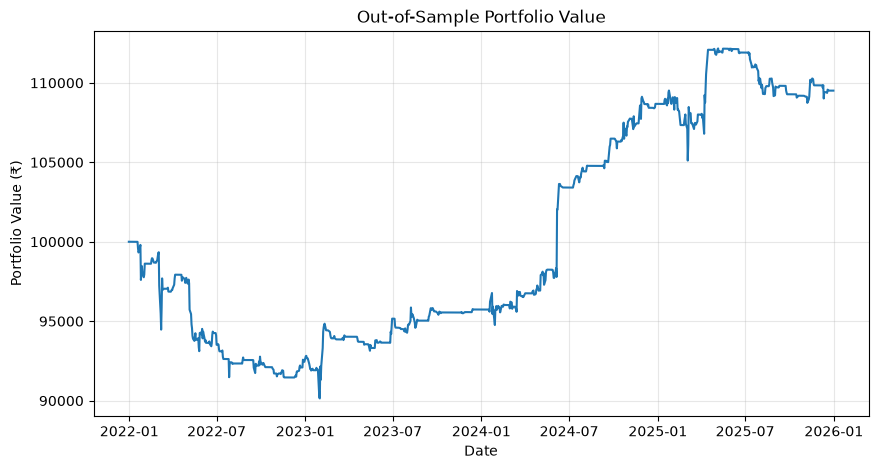

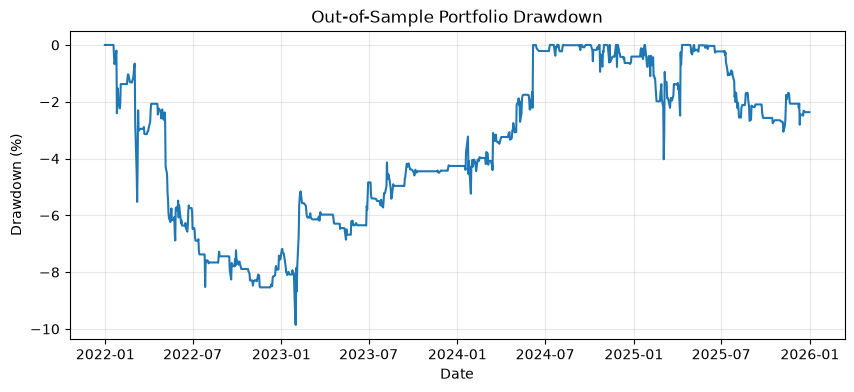

In [89]:
import matplotlib.pyplot as plt

# Portfolio value chart
plt.figure(figsize=(10, 5))
plt.plot(
    portfolio_results.index,
    portfolio_results["Portfolio Value"]
)

plt.title("Out-of-Sample Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.grid(True, alpha=0.3)
plt.show()


# Drawdown chart
plt.figure(figsize=(10, 4))
plt.plot(
    portfolio_results.index,
    portfolio_results["Drawdown"] * 100
)

plt.title("Out-of-Sample Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.show()

### Out-of-Sample Results

The realistic out-of-sample portfolio simulation produced a cumulative return of 9.51%, increasing an initial portfolio value of ₹100,000 to ₹109,510.22. The annualised return was 2.34%, with annualised volatility of 5.70% and a Sharpe ratio of 0.434. Maximum drawdown was -9.86%.

A total of 334 trades were executed. The win rate was 49.70% and the average net return per executed trade was 0.29%.

These results provide modest support for the hypothesis that extreme negative-return events accompanied by unusually high trading volume can be followed by short-term price reversal. However, the economic performance is not especially strong. In particular, the Sharpe ratio is below 1 and the portfolio experienced a drawdown close to 10%. Therefore, the results should be interpreted as evidence of a weak potential reversal effect rather than proof of a consistently profitable trading anomaly.

The win rate being slightly below 50% while the overall portfolio remained profitable also shows that profitability did not depend simply on winning more trades than losing. The size and timing of gains relative to losses also affected portfolio performance.

## 7. Methodological Pitfalls and Robustness

### Look-Ahead Bias

The strategy avoids look-ahead bias by constructing signals only from information available on or before the signal date. Rolling volume measures use lagged historical observations, and trades are entered on the following trading day rather than assuming execution before the signal information became available.

### Survivorship Bias

The equity universe is based on a fixed set of major Indian equities. This creates a potential survivorship-bias limitation because present-day constituents may not perfectly represent the investable universe throughout the full historical period. The results should therefore not be interpreted as a completely survivorship-bias-free estimate of historical performance. A more advanced extension would reconstruct historical index membership through time.

### Overfitting and Data Snooping

The strategy rules were specified using an in-sample period and subsequently evaluated on a separate out-of-sample period. The out-of-sample results were not used to repeatedly optimise thresholds until a preferred result was obtained. This separation reduces, although does not completely eliminate, the risk of overfitting and data snooping.

### Transaction Costs and Slippage

A round-trip transaction-cost assumption of 0.10% was incorporated into trade returns. This prevents the backtest from assuming completely frictionless trading. Actual trading costs and market impact could differ, particularly during unusually volatile market conditions, so realised live performance could be weaker.

### Out-of-Sample Testing

The historical sample was divided chronologically so that strategy development and evaluation were separated. The final portfolio results reported above are based on the out-of-sample period. This provides a more demanding test than evaluating the strategy only on the observations used during strategy development.

## 8. Risk and Efficiency Considerations

### Risk Management

The portfolio simulation begins with ₹100,000 of capital. Each individual position is limited to a maximum of 10% of portfolio value, while aggregate long exposure cannot exceed 100%. Unallocated capital remains in cash and no leverage is assumed.

These restrictions reduce concentration risk when many signals occur simultaneously. Nevertheless, the strategy remains exposed to equity-market risk, overnight price gaps and periods in which apparent overreaction is actually the beginning of a persistent decline.

A plausible adverse scenario is a broad market crisis in which many stocks experience extreme negative returns and unusually high volume simultaneously. In such an environment, the strategy could interpret genuine deterioration as temporary overreaction and enter several losing positions at approximately the same time.

### Computational Efficiency

The main computational operations involve processing daily observations across multiple stocks, calculating rolling statistics, generating signals and simulating trades through time. If T represents the number of trading days and N the number of stocks, the principal data-processing operations scale approximately with the number of stock-day observations, O(TN).

Vectorised pandas operations are used where practical for returns, rolling statistics and signal construction. The portfolio simulation requires sequential processing because portfolio value, available cash and open positions depend on previous trading decisions.

## 9. Conclusion and Reflection

This project investigated whether unusually large negative daily returns accompanied by unusually high trading volume in major Indian equities are followed by short-term price reversal.

The out-of-sample portfolio generated a positive cumulative return of 9.51%, but the annualised return was only 2.34% and the Sharpe ratio was 0.434. Maximum drawdown reached -9.86%. The results therefore provide some evidence consistent with short-term reversal, but they do not establish a strong or highly reliable trading anomaly.

One important lesson from the project is the distinction between identifying an interesting empirical pattern and constructing a realistic investable strategy. Individual trade returns alone are insufficient because overlapping signals, limited capital, transaction costs and position sizing materially affect portfolio-level results.

The project also demonstrates why methodological discipline matters in quantitative research. Look-ahead bias can produce impossible results, repeated parameter optimisation can create overfitting, and a present-day stock universe can introduce survivorship bias. Separating strategy development from out-of-sample evaluation makes the conclusions more credible.

If the research were extended, I would investigate historically reconstructed index membership, alternative definitions of extreme returns and abnormal volume, different market regimes and more detailed transaction-cost assumptions. These extensions should be treated as new robustness tests rather than repeatedly modifying the current model to improve its historical performance.

In [90]:
results_summary = pd.DataFrame({
    "Metric": [
        "Initial Portfolio Value",
        "Final Portfolio Value",
        "Cumulative Return",
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Executed Trades",
        "Win Rate",
        "Average Net Trade Return"
    ],
    "Value": [
        initial_value,
        final_value,
        cumulative_return,
        annualised_return,
        annualised_volatility,
        sharpe_ratio,
        max_drawdown,
        len(executed_trades_df),
        win_rate,
        average_trade_return
    ]
})

portfolio_results.to_csv(
    "data/oos_portfolio_results.csv"
)

executed_trades_df.to_csv(
    "data/oos_executed_trades.csv",
    index=False
)

results_summary.to_csv(
    "data/results_summary.csv",
    index=False
)

print("Results saved successfully.")
results_summary

Results saved successfully.


,Metric,Value
0,Initial Portfolio Value,100000.000000
1,Final Portfolio Value,109510.223364
2,Cumulative Return,0.095102
3,Annualised Return,0.023418
4,Annualised Volatility,0.057032
5,Sharpe Ratio,0.434245
6,Maximum Drawdown,-0.098599
7,Executed Trades,334.000000
8,Win Rate,0.497006
9,Average Net Trade Return,0.002917


## 10. Final Summary

This notebook developed and evaluated a quantitative short-term reversal strategy for major Indian equities. The strategy identifies unusually large negative-return events accompanied by elevated trading volume and tests whether prices subsequently reverse.

The research process included data acquisition and cleaning, feature construction, chronological in-sample/out-of-sample separation, signal generation, transaction-cost-adjusted trade evaluation, and a realistic portfolio simulation with position and exposure constraints.

In the out-of-sample portfolio test, ₹100,000 of initial capital increased to ₹109,510.22, representing a cumulative return of 9.51%. The annualised return was 2.34%, annualised volatility was 5.70%, the Sharpe ratio was 0.434, and maximum drawdown was -9.86%. A total of 334 trades were executed.

The findings provide modest evidence consistent with short-term reversal following extreme negative-return/high-volume events, but the risk-adjusted performance is not sufficiently strong to conclude that the strategy represents a robust trading anomaly. Methodological limitations, particularly survivorship bias, transaction-cost assumptions and possible regime dependence, remain important when interpreting the results.